In [1]:
from typing import TypedDict
from pprint import pprint
from langgraph.graph import StateGraph,START,END
from IPython.display import Image, display, JSON


In [2]:
class AgentState(TypedDict):
    num1: int
    num2: int
    operation: str
    result: int

In [3]:
def adder(state: AgentState) -> AgentState:
    state['result'] = state['num1'] + state['num2']
    return state

def subtractor(state: AgentState) -> AgentState:
    state['result'] = state['num1'] - state['num2']
    return state

def multipler(state: AgentState) -> AgentState:
    state['result'] = state['num1'] * state['num2']
    return state

def divider(state: AgentState) -> AgentState:
    state['result'] = state['num1'] / state['num2']
    return state

def decide_next_node(state: AgentState) -> str:
    """Decides which operation to perform based on the 'operation' field in the state."""
    if state['operation'] == 'add':
        return 'addition_operation'
    elif state['operation'] == 'subtract':
        return 'subtraction_operation'
    elif state['operation'] == 'multiply':
        return 'multiplication_operation'
    elif state['operation'] == 'divide':
        return 'division_operation'
    else:
        raise ValueError(f"Unknown operation: {state['operation']}")



In [4]:
graph = StateGraph(AgentState)

#nodes
graph.add_node('add_node', adder)
graph.add_node('subtract_node', subtractor)
graph.add_node('multiply_node', multipler)
graph.add_node('divide_node', divider)

# This node will decide which operation to perform based on the 'operation' field in the state
graph.add_node('router', lambda state: state) # This node will just pass the state through, the decision logic is in the edge


#edges
graph.add_edge(START, 'router')

#conditional edges based on the output of the decide_node
graph.add_conditional_edges(
    "router",
     decide_next_node,
    {
        #Edge : Node
        'addition_operation': 'add_node',
        'subtraction_operation': 'subtract_node',
        'multiplication_operation': 'multiply_node',
        'division_operation': 'divide_node'
    }
    
)

# Connect all operation nodes to END
graph.add_edge('add_node', END)
graph.add_edge('subtract_node', END)
graph.add_edge('multiply_node', END)
graph.add_edge('divide_node', END)

#compile the graph

app = graph.compile()


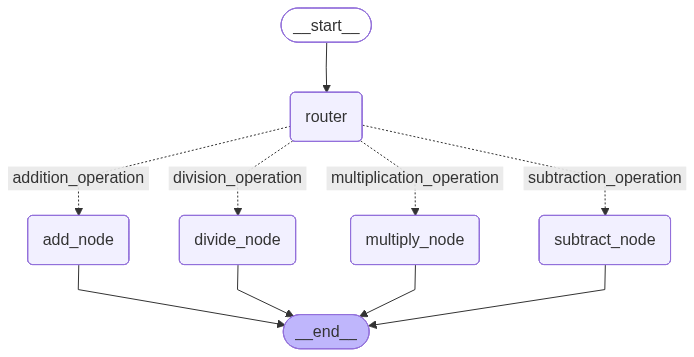

In [5]:
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [6]:
answers = app.invoke({
    'num1': 10,
    'num2': 5,
    'operation': 'divide'
})

#Create a agent state onject with the input values
agent_state: AgentState = {
    'num1': 10,
    'num2': 5,
    'operation': 'divide',
    'result': 0 # This will be updated by the nodes
}

# or

AgentState(num1=10, num2=5, operation='divide', result=0)



{'num1': 10, 'num2': 5, 'operation': 'divide', 'result': 0}

In [7]:
print("Final State:")
pprint(answers)

Final State:
{'num1': 10, 'num2': 5, 'operation': 'divide', 'result': 2.0}
